In [191]:
#Import stuff
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np

#Define functions from the lab instructions
def Skew(temp):
    skew = -30
    pres = np.arange(100,1001,1)
    return temp + skew * np.log(pres/1000)

def Skew2(temp):
    skew = -30
    return temp + skew * np.log(hPa_p/1000)

#For below functions: temp must be in Kelvin
def dry_lapse(temp, pres):
    return (Rd*temp)/(pres*cp)

def sat_vap_pres(temp):
    c = 6.112 #hPa
    return c*np.exp(17.67*(temp-273.15)/(temp-29.65))

def rs(temp, pres):
    e_s = sat_vap_pres(temp)
    return epsilon*(e_s/(pres-e_s))

def moist_lapse(temp, pres):
    r_s = rs(temp, pres)
    c = g/cp
    numer = 1 + ((Lv*r_s)/(Rd*temp))
    denom = 1 + (((Lv**2) * r_s)/(cp*Rv*(temp**2)))
    dT_dz = -c*numer/denom
    dT_dp = dT_dz * (Rv*temp)/(-pres*g)
    return dT_dp



#Set constants and limits from lab instructions
plines = np.arange(100, 1000, 100)
Tlines = np.arange(-100, 100, 10)
pmin, pmax = 100, 1000
Tmin, Tmax = -40, 50
epsilon = 0.622
g = 9.8
cp = 1004 #J/kgK
Rd = 287 #J/kgK
Rv = 461 #J/kgK
Lv = 2.5e6 #J/kg

K_T = Tlines + 273.15
hPa_p = np.flip(np.arange(100, 1001, 1))

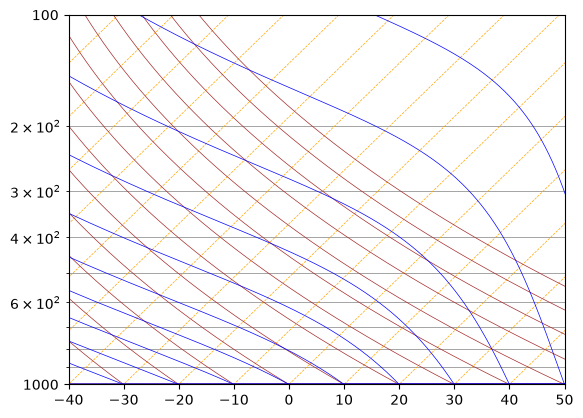

In [ ]:
#Plot the skew T
fig, ax = plt.subplots()

#Plot pressure and temperature lines, formatting to lab specifications
for p in plines:
    ax.hlines(p, xmin=Tmin, xmax=Tmax, color='gray', linewidths=.5)
for T in Tlines:
    ax.plot(Skew(T), np.arange(100, 1001,1), color='orange', linestyle='--', linewidth=.5)
ax.set_yscale('log') #This makes the y-axis (pressure) logarithmic
ax.set_ylim(pmax, pmin) #This sets the limits of the pressure axis provided in the lab
ax.set_xlim(Tmin, Tmax)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis='y', style='plain')  #This isn't working to remove the sci notation, need to find new way

#Plot the dry adiabats (might work?)
for temp in K_T:
    temps = [temp]
    t = temp
    for p in hPa_p[1:]:
        t = t - dry_lapse(t, p)
        temps.append(t-273.15)
    ax.plot(Skew2(temps), hPa_p, color='brown', linewidth=.5)

#Plot the moist adiabats (doesn't work yet)
for temp in K_T:
    temps = [temp]
    t = temp
    for p in hPa_p[1:]:
        t = t - moist_lapse(t, p)
        temps.append(t-273.15)
    ax.plot(Skew2(temps), hPa_p, color='blue', linewidth=.5)